In [1]:
# Import Dependencies
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2
from google.colab.patches import cv2_imshow
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from keras.models import Sequential

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Download dataset
!mkdir -p ~/.kaggle
!cp '/content/drive/MyDrive/kaggle.json' ~/.kaggle/
!kaggle datasets download omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown


In [3]:
# Unzip dataset
import zipfile
zip_file = zipfile.ZipFile('/content/face-mask-dataset.zip')
zip_file.extractall('/content')
zip_file.close()

In [4]:
with_mask_files = os.listdir('/content/data/with_mask')
without_mask_files = os.listdir('/content/data/without_mask')

print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


Creating labels of images

In [5]:
with_mask_labels = [1] * len(with_mask_files)
without_mask_labels = [0] * len(without_mask_files)

print(with_mask_labels[:5])
print(without_mask_labels[:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [6]:
labels = with_mask_labels + without_mask_labels

print(labels[:5])
print(labels[-5:])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


Displaying the images

In [7]:
data = []

for img_file in with_mask_files:
  image = Image.open('/content/data/with_mask/' + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

for img_file in without_mask_files:
  image = Image.open('/content/data/without_mask/' + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

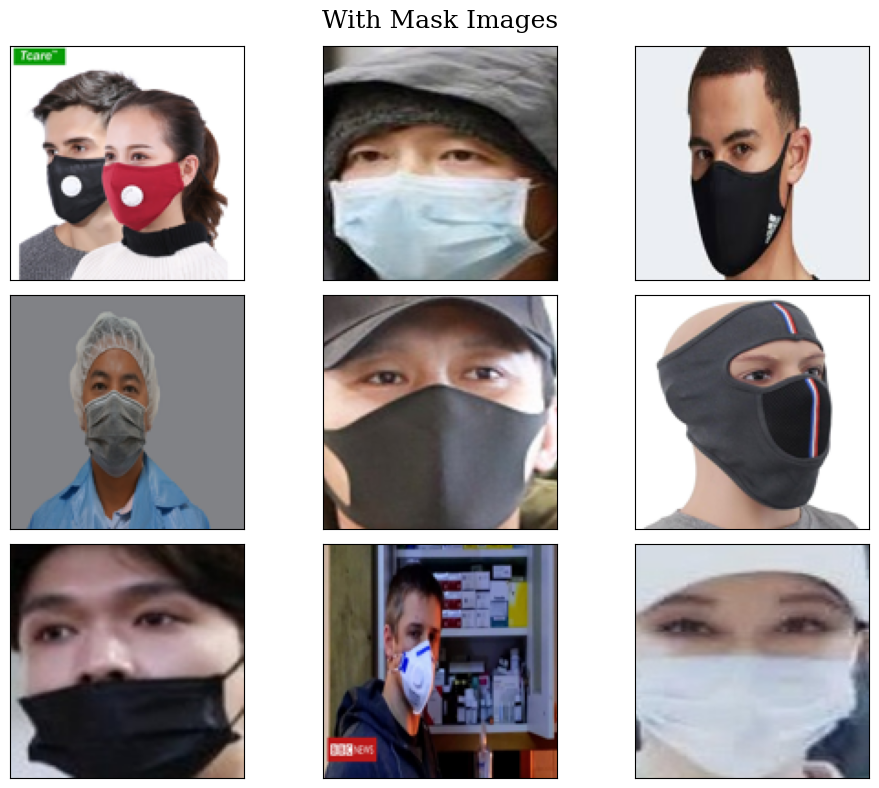

In [8]:
# With mask
plt.figure(figsize=(10,8))
idx = np.random.randint(0,len(with_mask_files),9)

for i in range(len(idx)):
  plt.subplot(3,3,i+1)
  plt.imshow(data[idx[i]])
  plt.xticks([])
  plt.yticks([])
  plt.suptitle('With Mask Images', size=18, family='serif')

plt.tight_layout()
plt.show()

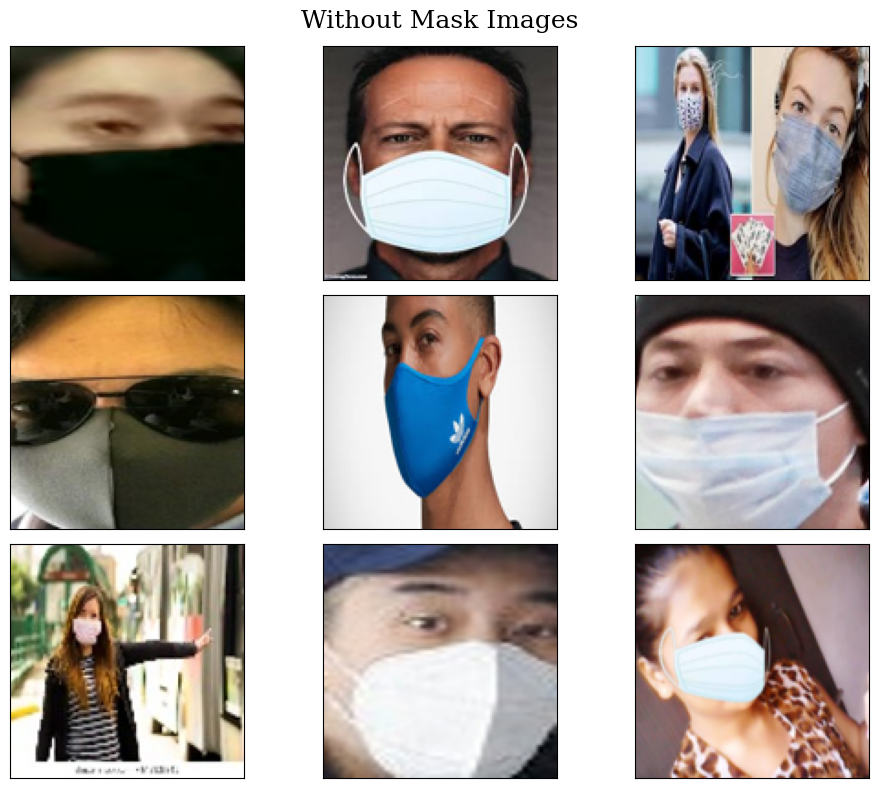

In [9]:
# Without mask images
plt.figure(figsize=(10,8))
idx = np.random.randint(0,len(without_mask_files),9)

for i in range(len(idx)):
  plt.subplot(3,3,i+1)
  plt.imshow(data[idx[i]])
  plt.xticks([])
  plt.yticks([])
  plt.suptitle('Without Mask Images', size=18, family='serif')

plt.tight_layout()
plt.show()

Converting Image list and Labels to numpy array

In [10]:
type(data[0])

numpy.ndarray

In [11]:
data[0].shape

(128, 128, 3)

In [12]:
type(labels)

list

In [13]:
x = np.array(data)
y = np.array(labels)

print(type(x))
print(type(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [14]:
print(x.shape)
print(y.shape)

(7553, 128, 128, 3)
(7553,)


Split into Training & Testing

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [16]:
print(x_train.shape)
print(x_test.shape)

(6042, 128, 128, 3)
(1511, 128, 128, 3)


Scaling the data

In [17]:
x_train_sc = x_train/255.0
x_test_sc = x_test/255.0

Building Convolutional Neural Network

In [24]:
model = Sequential()

# First Conv layer
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D())

# Second Conv layer
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D())

# Flatten
model.add(Flatten())

# First hidden layer
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.5))

# Second hidden layer
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.5))

# Output layer
model.add(Dense(units=2, activation='sigmoid'))

# Model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,400,706 (28.23 MB)

 Trainable params: 7,400,706 (28.23 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Model compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [26]:
# Training Neural Network
history = model.fit(x_train_sc, y_train, validation_split=0.1, epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.7485 - loss: 0.5872 - val_accuracy: 0.8744 - val_loss: 0.3196
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8871 - loss: 0.2950 - val_accuracy: 0.8529 - val_loss: 0.3321
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8993 - loss: 0.2521 - val_accuracy: 0.9025 - val_loss: 0.2457
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9222 - loss: 0.2084 - val_accuracy: 0.9240 - val_loss: 0.2384
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9453 - loss: 0.1543 - val_accuracy: 0.9174 - val_loss: 0.2179


Model Evaluation

In [27]:
loss, accuracy = model.evaluate(x_test_sc, y_test)
print('Test Accuracy:', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9313 - loss: 0.1976
Test Accuracy: 0.9166114926338196


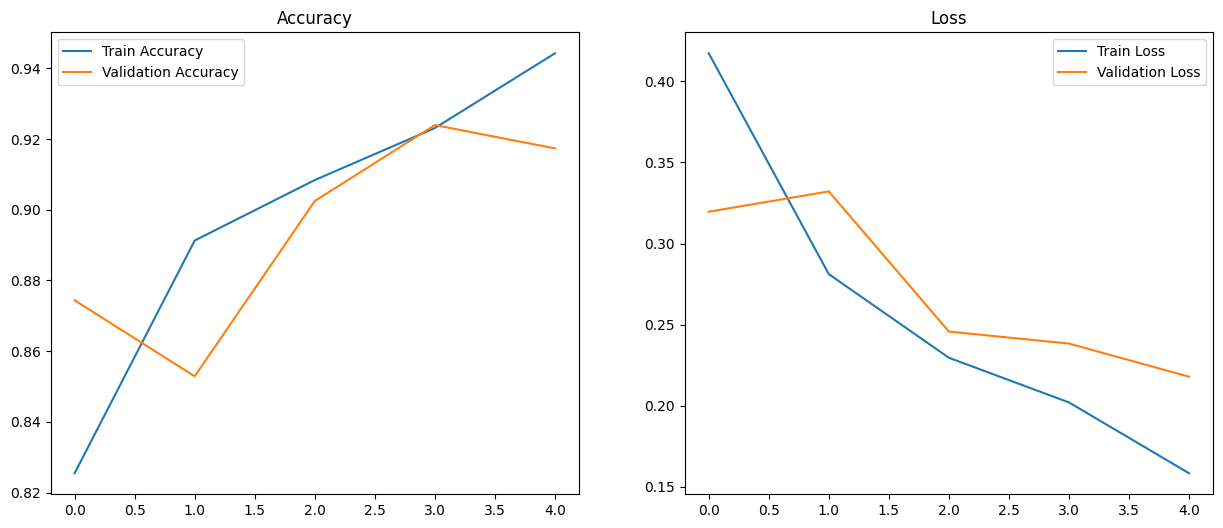

In [40]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label=['Train Accuracy'])
plt.plot(history.history['val_accuracy'], label=['Validation Accuracy'])
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label=['Train Loss'])
plt.plot(history.history['val_loss'], label=['Validation Loss'])
plt.title('Loss')
plt.legend()

plt.show()

Prediction

In [43]:
def prediction(img_path):
  # Read image
  img_read = cv2.imread(img_path)
  cv2_imshow(img_read)
  # resize
  img_resize = cv2.resize(img_read, (128,128))
  # Scalling
  img_scaled = img_resize / 255.0
  # Reshape
  img_reshape = np.reshape(img_scaled, [1,128,128,3])
  # Predict Probability
  pred_prob = model.predict(img_reshape)
  print(pred_prob)
  # Pring Label
  pred_label = np.argmax(pred_prob)
  if pred_label == 1:
    print('The person in the image is wearing a mask.')
  else:
    print('The person in the image is not wearing a mask.')

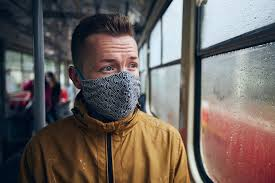

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
[[0.388307   0.60679144]]
The person in the image is wearing a mask.


In [45]:
prediction('/content/Untitled.jpg')

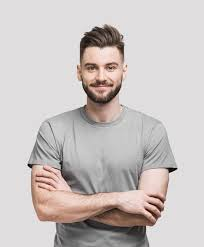

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
[[0.52599925 0.49712828]]
The person in the image is not wearing a mask.


In [48]:
prediction('/content/Untitled1.jpg')